# EIA 930: Region TI vs Sum-of-BA-Interchange

EIA publishes two independent series for California's total interchange:

1. **Region series** (`eia_rto-region-data_CAL_*.csv`, type=`TI`) — EIA's aggregate for the CAL
   super-region (positive = net exports).
2. **BA-level interchange** (`eia_interchange.csv`) — individual flows between each of the 8 CA
   balancing authorities and their counterparts.

These come from the same EIA 930 survey but can differ because:
- The CAL region boundary does not perfectly align with the 8 individual BAs (e.g. PACW spans
  Oregon/Washington/Idaho/California; NEVP is primarily Nevada).
- Inter-CA flows (BANC↔CISO etc.) cancel when summing properly but measurement discrepancies
  between BAs leave a residual.
- EIA may apply different imputation / revision rules at the region vs BA level.

This notebook quantifies how much the two series agree.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ROOT  = Path().resolve().parent
RAW   = ROOT / 'data' / 'raw'  / 'eia'
PROC  = ROOT / 'data' / 'processed' / 'eia'

CA8 = frozenset({'BANC', 'CISO', 'IID', 'LDWP', 'NEVP', 'PACW', 'TIDC', 'WALC'})

# Processed interchange (fromba always in CA8)
print('Loading processed interchange ...')
ic = pd.read_csv(PROC / 'eia_interchange.csv', low_memory=False)
print(f'  {len(ic):,} rows, periods: {ic["period"].min()} to {ic["period"].max()}')

# Region TI
print('Loading region data ...')
reg_raw = pd.read_csv(RAW / 'eia_rto-region-data_CAL_earliest_latest_part001.csv')
reg_ti  = reg_raw[reg_raw['type'] == 'TI'][['period', 'value']].rename(columns={'value': 'region_ti'})
print(f'  {len(reg_ti):,} TI rows')

Loading processed interchange ...
  3,071,255 rows, periods: 2019-01-01T00 to 2026-05-30T07
Loading region data ...
  64,951 TI rows


## Approach 1 — Sum all CA-8 flows to outside BAs (`toba` not in CA8)

For California as a whole, internal CA→CA flows cancel in the aggregate.  The net interchange
for the CAL region equals the sum of all flows crossing the CA8 boundary to external BAs.

`net_ca_export = Σ value  where (fromba ∈ CA8) and (toba ∉ CA8)`

In [2]:
external = ic[~ic['toba'].isin(CA8)].copy()
sum_external = (
    external
    .groupby('period')['value']
    .sum()
    .rename('ic_sum_external')
    .reset_index()
)
print(f'Periods with external flows: {len(sum_external):,}')
print(sum_external['ic_sum_external'].describe())

Periods with external flows: 64,952
count     64952.000000
mean      -7756.426577
std        2850.325084
min     -110647.000000
25%       -9740.250000
50%       -8008.000000
75%       -6063.000000
max        2898.000000
Name: ic_sum_external, dtype: float64


## Approach 2 — Sum all CA-8 flows (including inter-CA)

Including inter-8 flows (they should cancel but don't always due to BA reporting discrepancies).

`net_ca_all = Σ value  where fromba ∈ CA8`

In [3]:
sum_all = (
    ic
    .groupby('period')['value']
    .sum()
    .rename('ic_sum_all')
    .reset_index()
)
print(f'Periods with any flows: {len(sum_all):,}')

Periods with any flows: 64,952


## Merge and compare

In [4]:
cmp = (
    reg_ti
    .merge(sum_external, on='period', how='left')
    .merge(sum_all,      on='period', how='left')
)

cmp['diff_external'] = cmp['ic_sum_external'] - cmp['region_ti']
cmp['diff_all']      = cmp['ic_sum_all']      - cmp['region_ti']

print(f'Rows in comparison: {len(cmp):,}')
print()
print('--- ic_sum_external vs region_ti ---')
print(cmp['diff_external'].describe())
print()
print('--- ic_sum_all vs region_ti ---')
print(cmp['diff_all'].describe())

Rows in comparison: 64,951

--- ic_sum_external vs region_ti ---
count     64951.000000
mean      -1814.305908
std        1056.519633
min     -107361.000000
25%       -2290.000000
50%       -1700.000000
75%       -1188.000000
max        3415.000000
Name: diff_external, dtype: float64

--- ic_sum_all vs region_ti ---
count    6.495100e+04
mean     1.027322e+03
std      5.809462e+04
min     -1.076350e+05
25%     -2.441000e+03
50%     -1.824000e+03
75%     -1.281000e+03
max      3.291871e+06
Name: diff_all, dtype: float64


In [5]:
# Quick agreement summary
for label, col in [('external only', 'diff_external'), ('all flows', 'diff_all')]:
    d = cmp[col].dropna()
    within_100  = (d.abs() <= 100).mean() * 100
    within_500  = (d.abs() <= 500).mean() * 100
    within_1000 = (d.abs() <= 1000).mean() * 100
    print(f'{label}:')
    print(f'  |diff| <= 100 MWh : {within_100:.1f}%')
    print(f'  |diff| <= 500 MWh : {within_500:.1f}%')
    print(f'  |diff| <=1000 MWh : {within_1000:.1f}%')
    print(f'  RMSE              : {np.sqrt((d**2).mean()):.1f} MWh')
    print(f'  Mean bias         : {d.mean():.1f} MWh')
    print()

external only:
  |diff| <= 100 MWh : 0.7%
  |diff| <= 500 MWh : 4.8%
  |diff| <=1000 MWh : 17.6%
  RMSE              : 2099.5 MWh
  Mean bias         : -1814.3 MWh

all flows:
  |diff| <= 100 MWh : 0.6%
  |diff| <= 500 MWh : 3.8%
  |diff| <=1000 MWh : 14.4%
  RMSE              : 58103.3 MWh
  Mean bias         : 1027.3 MWh



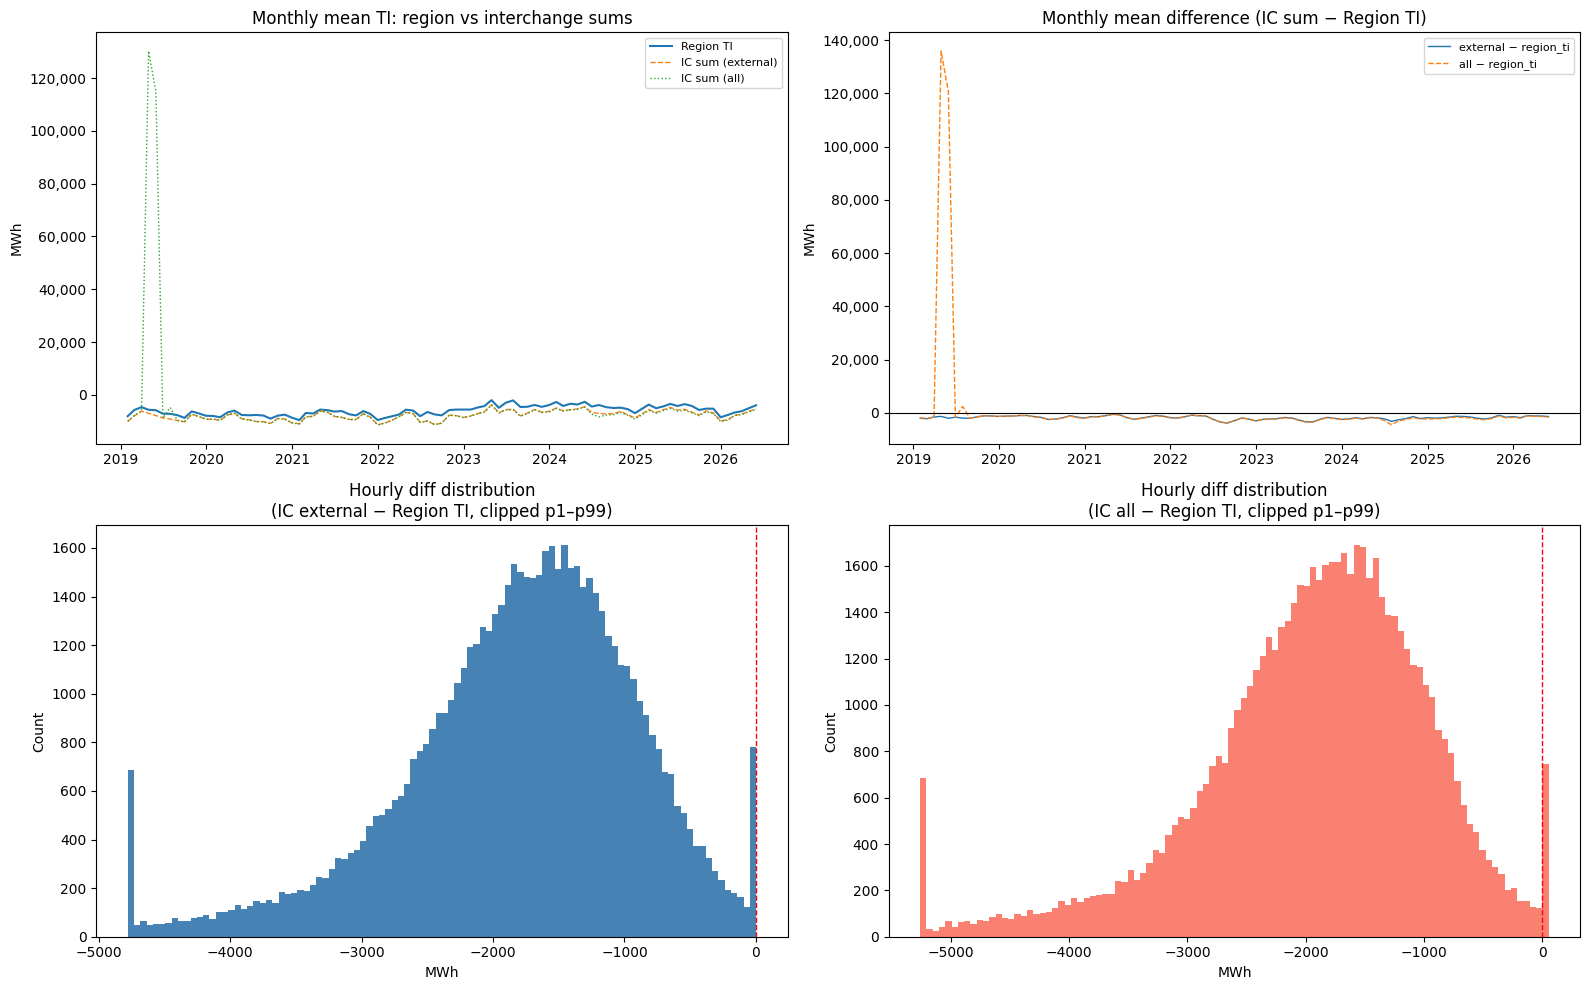

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time series: region TI vs two IC sums
cmp['dt'] = pd.to_datetime(cmp['period'].str[:10])
monthly = cmp.set_index('dt').resample('ME').mean(numeric_only=True)

ax = axes[0, 0]
ax.plot(monthly.index, monthly['region_ti'],      label='Region TI', lw=1.5)
ax.plot(monthly.index, monthly['ic_sum_external'], label='IC sum (external)', lw=1, ls='--')
ax.plot(monthly.index, monthly['ic_sum_all'],      label='IC sum (all)',      lw=1, ls=':')
ax.set_title('Monthly mean TI: region vs interchange sums')
ax.set_ylabel('MWh')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)

# Diff time series
ax = axes[0, 1]
ax.plot(monthly.index, monthly['diff_external'], label='external − region_ti', lw=1)
ax.plot(monthly.index, monthly['diff_all'],      label='all − region_ti',      lw=1, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Monthly mean difference (IC sum − Region TI)')
ax.set_ylabel('MWh')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)

# Distribution of hourly diff_external
ax = axes[1, 0]
d = cmp['diff_external'].dropna()
lo, hi = np.percentile(d, [1, 99])
ax.hist(d.clip(lo, hi), bins=100, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', lw=1, ls='--')
ax.set_title('Hourly diff distribution\n(IC external − Region TI, clipped p1–p99)')
ax.set_xlabel('MWh')
ax.set_ylabel('Count')

# Distribution of hourly diff_all
ax = axes[1, 1]
d = cmp['diff_all'].dropna()
lo, hi = np.percentile(d, [1, 99])
ax.hist(d.clip(lo, hi), bins=100, color='salmon', edgecolor='none')
ax.axvline(0, color='red', lw=1, ls='--')
ax.set_title('Hourly diff distribution\n(IC all − Region TI, clipped p1–p99)')
ax.set_xlabel('MWh')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Per-BA contribution to the difference

Which BAs contribute most to the gap between the interchange sum and the region TI?

In [7]:
# Net external interchange per BA per period
ba_ext = (
    external
    .groupby(['period', 'fromba'])['value']
    .sum()
    .unstack(fill_value=0)
)
ba_ext['ic_sum_external'] = ba_ext.sum(axis=1)
ba_ext = ba_ext.merge(reg_ti.set_index('period'), left_index=True, right_index=True, how='left')
ba_ext['diff'] = ba_ext['ic_sum_external'] - ba_ext['region_ti']

print('Correlation of each BA\'s external net interchange with the total diff:')
for ba in sorted(CA8):
    if ba in ba_ext.columns:
        c = ba_ext[ba].corr(ba_ext['diff'])
        print(f'  {ba:8s}  r = {c:.3f}')

Correlation of each BA's external net interchange with the total diff:
  BANC      r = -0.115
  CISO      r = -0.151
  IID       r = -0.017
  LDWP      r = 0.040
  NEVP      r = -0.027
  PACW      r = 0.682
  WALC      r = 0.026


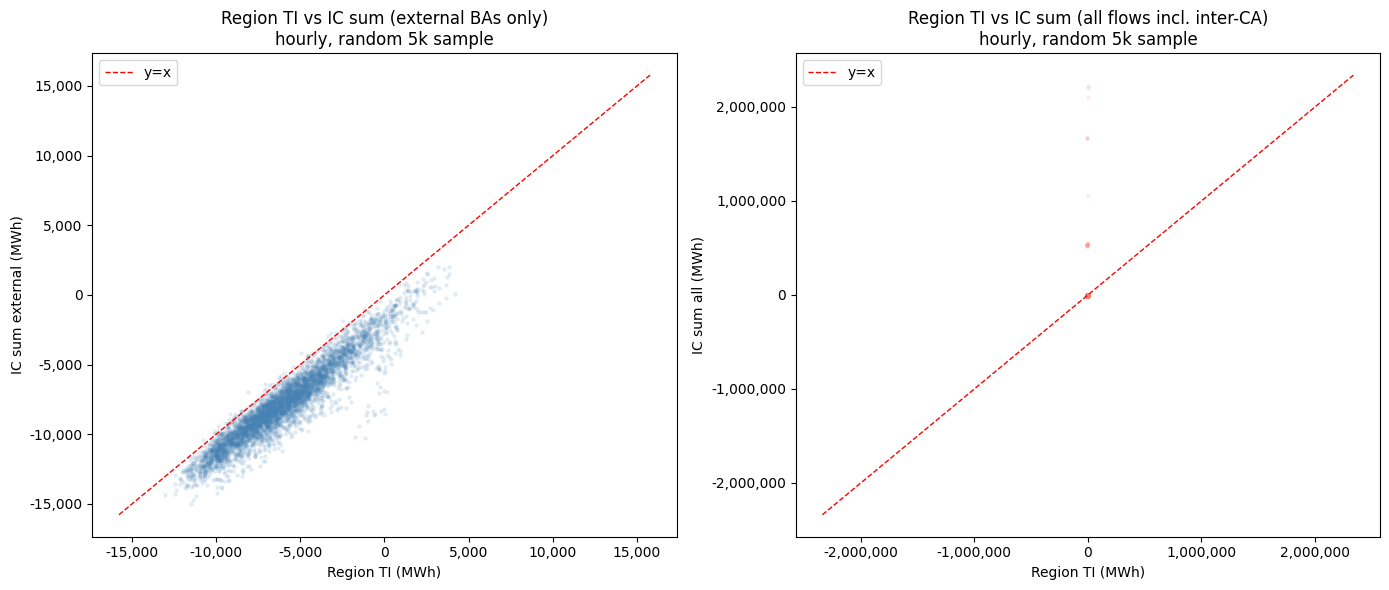

In [8]:
# Scatter: region TI vs IC sum (external)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = cmp.dropna(subset=['ic_sum_external', 'region_ti']).sample(min(5000, len(cmp)), random_state=42)

ax = axes[0]
ax.scatter(sample['region_ti'], sample['ic_sum_external'], alpha=0.1, s=5, color='steelblue')
lim = max(sample['region_ti'].abs().max(), sample['ic_sum_external'].abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
ax.set_xlabel('Region TI (MWh)')
ax.set_ylabel('IC sum external (MWh)')
ax.set_title('Region TI vs IC sum (external BAs only)\nhourly, random 5k sample')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
ax.scatter(sample['region_ti'], sample['ic_sum_all'], alpha=0.1, s=5, color='salmon')
lim = max(sample['region_ti'].abs().max(), sample['ic_sum_all'].abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
ax.set_xlabel('Region TI (MWh)')
ax.set_ylabel('IC sum all (MWh)')
ax.set_title('Region TI vs IC sum (all flows incl. inter-CA)\nhourly, random 5k sample')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [9]:
# Largest discrepancy hours — for manual investigation
top_diff = (
    cmp[['period', 'region_ti', 'ic_sum_external', 'ic_sum_all', 'diff_external', 'diff_all']]
    .dropna()
    .assign(abs_diff=cmp['diff_external'].abs())
    .sort_values('abs_diff', ascending=False)
    .head(20)
    .drop(columns='abs_diff')
)
print('20 hours with largest |diff_external|:')
print(top_diff.to_string(index=False))

20 hours with largest |diff_external|:
       period  region_ti  ic_sum_external  ic_sum_all  diff_external  diff_all
2019-05-07T18      -3286          -110647     -110921        -107361   -107635
2024-05-18T07      -1233           -11939       -7483         -10706     -6250
2024-05-18T05      -1067           -11745       -7391         -10678     -6324
2024-05-18T06      -1064           -11658       -7211         -10594     -6147
2024-05-18T04      -1301           -11692       -7510         -10391     -6209
2024-05-18T08      -1583           -11955      -12104         -10372    -10521
2024-05-18T09      -1502           -11721      -11867         -10219    -10365
2024-05-21T13       -802           -10567      -10690          -9765     -9888
2025-11-02T06       -682           -10435      -11295          -9753    -10613
2024-05-21T08       -894           -10603      -10724          -9709     -9830
2024-05-18T10      -1360           -10969      -11110          -9609     -9750
2026-03-08T08